In [ ]:
import os.path as osp
import sys
sys.path.append('../')
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

import numpy as np
from sklearn import metrics, calibration

import matplotlib.pyplot as plt
import matplotlib

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import qdre
import Camel.equations as equations

from qdre.plotting import get_scores, get_r_hats
from evaluation_helpers import plot_closure

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


In [2]:
SAVE_DIR = "./models"
DATA_DIR = "./data"

In [3]:
"""
Dataset options: mc, negative
"""

DATASET = "mc"


if DATASET == "mc":
    source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
    target_file = osp.join(DATA_DIR, "target_distribution_mc_data")
elif DATASET == "negative":
    source_file = osp.join(DATA_DIR, "base_distribution_mc_data")
    target_file = osp.join(DATA_DIR, "target_negative_distribution_mc_data")

In [4]:
batch_size = int(2**8)

model_paths = [osp.join(SAVE_DIR,"classifier_subdensity_{}_batch{}.zip".format(i+1, batch_size)) for i in range(4)]

training_settings = [qdre.train.load_training_settings(model_path) for model_path in model_paths]

models = [qdre.models.load_model(model_path, device=DEVICE).to(DEVICE) for model_path in model_paths]

# Get the analytical optimal classifier
s_optimals = [equations.optimal_binary_classifier(training_settings[i]["source_mixture_coef"],
                                                  training_settings[i]["source_scales"],
                                                  training_settings[i]["target_mixture_coef"],
                                                  training_settings[i]["target_scales"]) for i in range(4)]



training_settings[0].keys()

dict_keys(['batch_size', 'learning_rate', 'n_epochs', 'n_test', 'n_train', 'n_val', 'optimal_train_loss', 'optimal_valid_loss', 'optimizer', 'random_seed', 'source_file', 'source_mixture_coef', 'source_scales', 'target_file', 'target_mixture_coef', 'target_scales', 'training_losses', 'validation_losses'])

In [5]:
source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

combos = [np.array((0,2)), #++
          np.array((0,3)), #+-
          np.array((1,2)), #-+
          np.array((1,3))] #--

train_datasizes = []
val_datasizes = []
test_datasizes = []
for f in files:
    train_datasizes.append(np.load(f + "_train.npy").shape[0])
    val_datasizes.append(np.load(f + "_val.npy").shape[0])
    test_datasizes.append(np.load(f + "_test.npy").shape[0])

train_datasizes = np.array(train_datasizes)
val_datasizes = np.array(val_datasizes)
test_datasizes = np.array(test_datasizes)
train_datasizes

array([1600782,  399218, 1334428,  665572])

In [6]:
test_generator_datas = []
for i in range(4):
    test_base_dataset = qdre.preprocessing.Dataset(files[combos[i][0]] + "_test.npy", 0,
                                                    stop_event=training_settings[i]["n_test"])

    test_target_dataset = qdre.preprocessing.Dataset(files[combos[i][1]] + "_test.npy", 1,
                                                    stop_event=training_settings[i]["n_test"])

    weight_norm = 1
    if combos[i][0] == 1:
        weight_norm = -1
    test_base_dataset.process(normalize_weights=True, weight_norm=weight_norm)

    weight_norm = 1
    if combos[i][1] == 3:
        weight_norm = -1
    test_target_dataset.process(normalize_weights=True, weight_norm=weight_norm)
    
    test_generator_datas.append(qdre.preprocessing.CombinedDataset(test_base_dataset, test_target_dataset))

In [7]:
X_scalers, weight_norms = list(zip(*[qdre.preprocessing.load_scaling(model_path) for model_path in model_paths]))

0.6696372258423006
0.5033577970597564
0.6838338260320906
0.5373379209574233


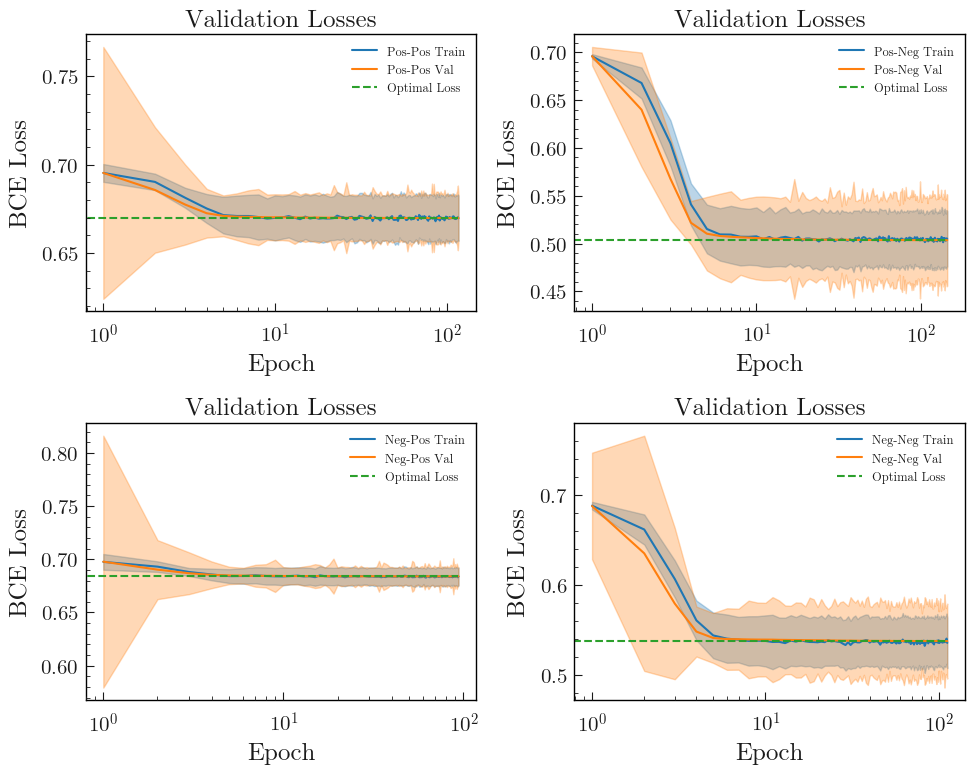

In [8]:
fig,ax = plt.subplots(2,2)
fig.set_size_inches(10,8)

training_losses = [ts["training_losses"] for ts in training_settings]
validation_losses = [ts["validation_losses"] for ts in training_settings]

starting_epoch = 0

training_loss_per_epoch = [np.array(tl[starting_epoch:]).mean(axis=1) for tl in training_losses]
training_std_per_epoch = [np.array(tl[starting_epoch:]).std(axis=1) for tl in training_losses]

validation_loss_per_epoch = [np.array(vl[starting_epoch:]).mean(axis=1) for i, vl in enumerate(validation_losses)]
validation_std_per_epoch = [np.array(vl[starting_epoch:]).std(axis=1) for i, vl in enumerate(validation_losses)]

training_lower_bar = [training_loss_per_epoch[i] - training_std_per_epoch[i] for i in range(4)]
training_upper_bar = [training_loss_per_epoch[i] + training_std_per_epoch[i] for i in range(4)]

validation_lower_bar = [validation_loss_per_epoch[i] - validation_std_per_epoch[i] for i in range(4)]
validation_upper_bar = [validation_loss_per_epoch[i] + validation_std_per_epoch[i] for i in range(4)]


t = [np.arange(len(validation_loss_per_epoch[i])) + 1 for i in range(4)]
names = ["Pos-Pos", "Pos-Neg", "Neg-Pos", "Neg-Neg"]

for i in range(4):
    ax[i//2, i%2].plot(t[i], training_loss_per_epoch[i], label=names[i]+" Train", color="tab:blue")
    ax[i//2, i%2].fill_between(t[i], training_lower_bar[i], training_upper_bar[i], color='tab:blue', alpha=0.30)
    ax[i//2, i%2].plot(t[i], validation_loss_per_epoch[i], label=names[i]+" Val", color="tab:orange")
    ax[i//2, i%2].fill_between(t[i], validation_lower_bar[i], validation_upper_bar[i], color='tab:orange', alpha=0.30)
    ax[i//2, i%2].plot([0, t[i].max()], [training_settings[i]["optimal_valid_loss"]]*2, '--', label="Optimal Loss", color="tab:green")
    print(training_settings[i]["optimal_valid_loss"])

    ax[i//2, i%2].legend(prop={'size': 9})
    ax[i//2, i%2].set_xlabel("Epoch")
    ax[i//2, i%2].set_ylabel("BCE Loss")
    ax[i//2, i%2].set_title("Validation Losses")
    ax[i//2, i%2].set_xscale('log')
    #ax[i//2, i%2].set_yscale('log')
    #ax[i//2, i%2].set_ylim([min([validation_lower_bar[i][1:].min(), training_settings[i]["optimal_valid_loss"]]), 0.7])

fig.tight_layout()

## Get the scores (model output) on the test data

In [9]:
batch_size = 1024
test_loaders = [DataLoader(test_generator_data, batch_size=batch_size, shuffle=False) for test_generator_data in test_generator_datas]

In [10]:
test_scores, test_targets, test_weights = list(zip(*[get_scores(
    models[i],
    test_loaders[i],
    X_scalers[i],
    leave=True,
    device=DEVICE
) for i in range(4)]))

100%|██████████| 546/546 [00:04<00:00, 133.61it/s]


In [11]:
opt_test_scores, opt_test_targets, opt_test_weights = list(zip(*[get_scores(
    s_optimals[i],
    test_loaders[i],
    X_scalers[i], # wont be used
    leave=True,
    device=DEVICE
) for i in range(4)]))

100%|██████████| 546/546 [00:05<00:00, 91.19it/s] 


In [12]:
prob_true, prob_pred = list(zip(*[calibration.calibration_curve(
    test_targets[i],
    test_scores[i],
    n_bins=20
) for i in range(4)]))

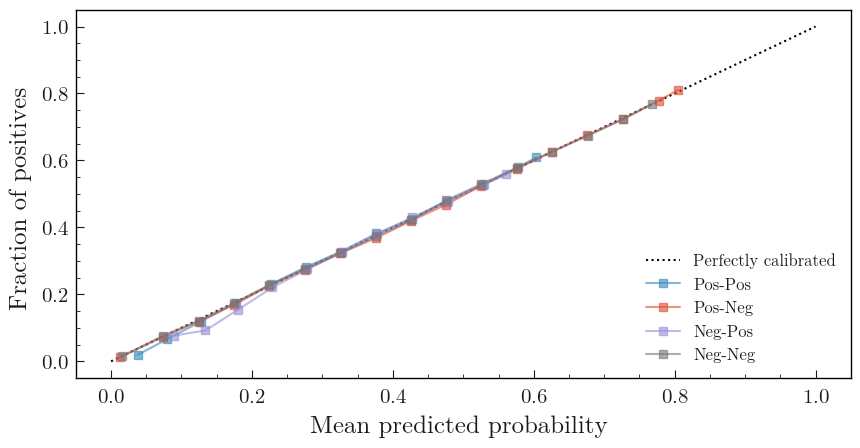

In [13]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(4, 2)
ax_calibration_curve = fig.add_subplot(gs[:2, :2])

names = ["Pos-Pos", "Pos-Neg", "Neg-Pos", "Neg-Neg"]
disp = [calibration.CalibrationDisplay(prob_true[i], prob_pred[i], test_scores[i], estimator_name=names[i]) for i in range(4)]

[d.plot(ax=ax_calibration_curve, alpha=0.6) for d in disp]
#disp[0].plot()

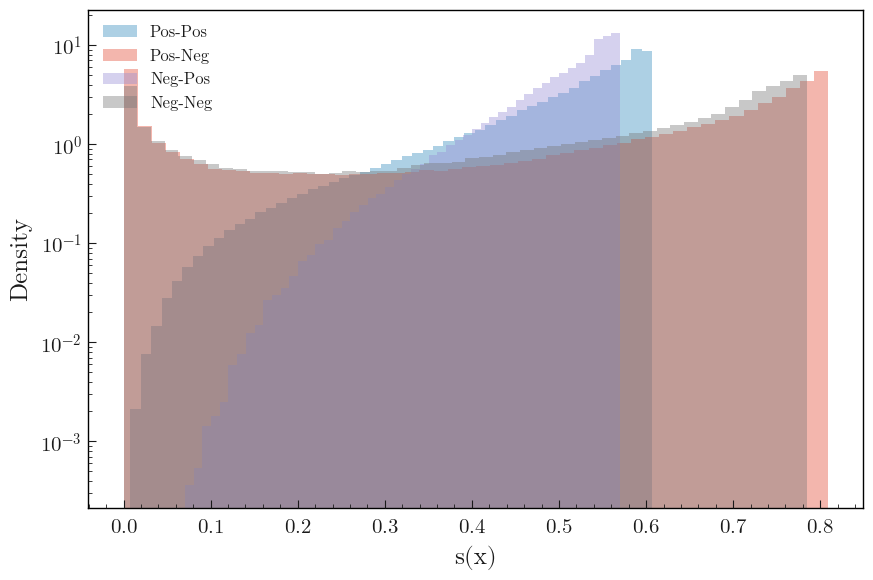

In [14]:
fig = plt.figure(figsize=(10, 10))
gs = matplotlib.gridspec.GridSpec(3, 2)
ax = fig.add_subplot(gs[:2, :2])

names = ["Pos-Pos", "Pos-Neg", "Neg-Pos", "Neg-Neg"]
hist = [ax.hist(test_scores[i], weights=test_weights[i], bins=50, alpha=0.4, density=True, label=names[i]) for i in range(4)]

ax.legend()
ax.set_xlabel("s(x)")
ax.set_ylabel("Density")
ax.set_yscale('log')
#[d.plot(ax=ax_calibration_curve, alpha=0.6) for d in disp]
#disp[0].plot()

## Evaluate the ROC curve for the model

In [15]:
auc_scores = [metrics.roc_auc_score(test_targets[i], test_scores[i], sample_weight=test_weights[i]) for i in range(4)]
opt_auc_scores = [metrics.roc_auc_score(opt_test_targets[i], opt_test_scores[i], sample_weight=opt_test_weights[i]) for i in range(4)]

print("Area under the ROC curve for the subdensities: [{:.4}, {:.4}, {:.4}, {:.4}]".format(*auc_scores))
print("Area under the ROC curve for the optimals: [{:.4}, {:.4}, {:.4}, {:.4}]".format(*opt_auc_scores))

Area under the ROC curve for the subdensities: [0.6105, 0.8134, 0.5683, 0.7857]
Area under the ROC curve for the optimals: [0.6105, 0.8135, 0.5685, 0.7857]


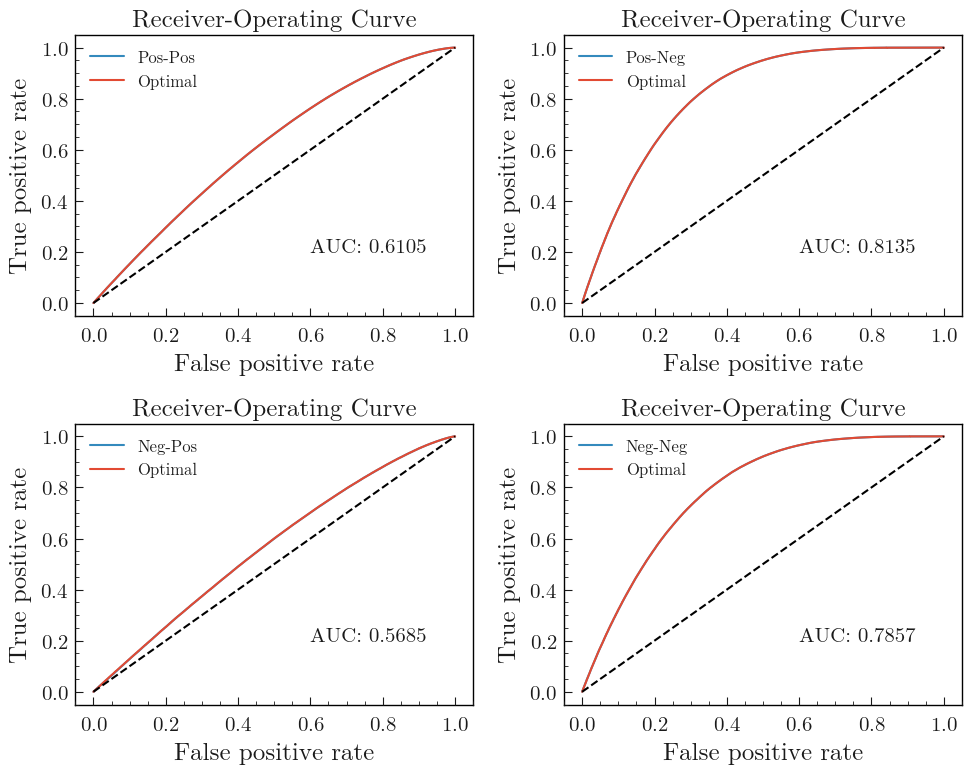

In [16]:
fpr, tpr, thresholds = list(zip(*[metrics.roc_curve(test_targets[i], test_scores[i], pos_label=1, sample_weight=test_weights[i]) for i in range(4)]))
opt_fpr, opt_tpr, opt_thresholds = list(zip(*[metrics.roc_curve(opt_test_targets[i], opt_test_scores[i], pos_label=1, sample_weight=opt_test_weights[i]) for i in range(4)]))

fig,ax = plt.subplots(2,2)
fig.set_size_inches(10,8)

names = ["Pos-Pos", "Pos-Neg", "Neg-Pos", "Neg-Neg"]

for i in range(4):
    ax[i//2,i%2].plot(fpr[i], tpr[i], label=names[i])
    #ax[i//2,i%2].plot(fpr2[i], tpr2[i], label=names[i] + "+")
    ax[i//2,i%2].plot(opt_fpr[i], opt_tpr[i], label="Optimal")
    ax[i//2,i%2].plot(np.linspace(0,1,20), np.linspace(0,1,20), '--', c="black")
    ax[i//2,i%2].set_xlabel("False positive rate")
    ax[i//2,i%2].set_ylabel("True positive rate")
    ax[i//2,i%2].set_title("Receiver-Operating Curve")
    ax[i//2,i%2].legend()
    ax[i//2,i%2].text(0.6, 0.2, "AUC: {:.4}".format(opt_auc_scores[i]));

fig.tight_layout()

## Get the CARL weights

In [17]:
test_nominal_loaders = []
test_target_loaders = []
for i in range(4):
# We flip the labels here so we learn the ratio of Y=0/Y=1 when we use the regular s/(1-s) trick, which is what we want for the subdensities
    test_base_dataset = qdre.preprocessing.Dataset(files[combos[i][0]] +"_test.npy", 0,
                                                    stop_event=training_settings[i]["n_test"])
    
    test_target_dataset = qdre.preprocessing.Dataset(files[combos[i][1]] +"_test.npy", 1,
                                                    stop_event=training_settings[i]["n_test"])

    weight_norm = 1
    if combos[i][0] == 1:
        weight_norm = -1
    test_base_dataset.process(normalize_weights=True, weight_norm=weight_norm)
    
    weight_norm = 1
    if combos[i][1] == 3:
        weight_norm = -1
    test_target_dataset.process(normalize_weights=True, weight_norm=weight_norm)

    test_nominal_loaders.append(DataLoader(qdre.preprocessing.CombinedDataset(test_base_dataset), batch_size=batch_size, shuffle=False))
    test_target_loaders.append(DataLoader(qdre.preprocessing.CombinedDataset(test_target_dataset), batch_size=batch_size, shuffle=False))

In [18]:
r_hats = [get_r_hats(
            models[i],
            test_nominal_loaders[i],
            X_scalers[i],
            leave=True,
            device=DEVICE
) for i in range(4)]

100%|██████████| 273/273 [00:12<00:00, 21.57it/s]


In [19]:
opt_r_hats = [get_r_hats(
            s_optimals[i],
            test_nominal_loaders[i],
            X_scalers[i], # wont be used
            leave=True,
            device=DEVICE
) for i in range(4)]

100%|██████████| 273/273 [00:11<00:00, 24.01it/s]


## Plot the reweighted distributions

In [20]:
distribution_names = [["+", "+"],
                      ["+", "-"],
                      ["-", "+"],
                      ["-", "-"]]

model_names = [["{} CARL".format(names[i]), "Optimal"] for i in range(4)]
nominal_distribution_names = ['{} Reference'.format(distribution_names[i][0]) for i in range(4)]
target_distribution_names = ['{} Target'.format(distribution_names[i][1]) for i in range(4)]
paired_ratios = list(zip(r_hats, opt_r_hats))

  1%|          | 5/911 [00:00<00:23, 37.83it/s]

/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:480: RuntimeWarning: divide by zero encountered in divide
  x1_ratio = x0_hist/x1_hist
/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:484: RuntimeWarning: divide by zero encountered in divide
  carl_ratio = [carl_hist[0]/x1_hist for carl_hist in carl_hists]
/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:526: RuntimeWarning: invalid value encountered in scalar divide
  binsqrsum_x1 = binsqrsum_x1/w1[mask1].sum()


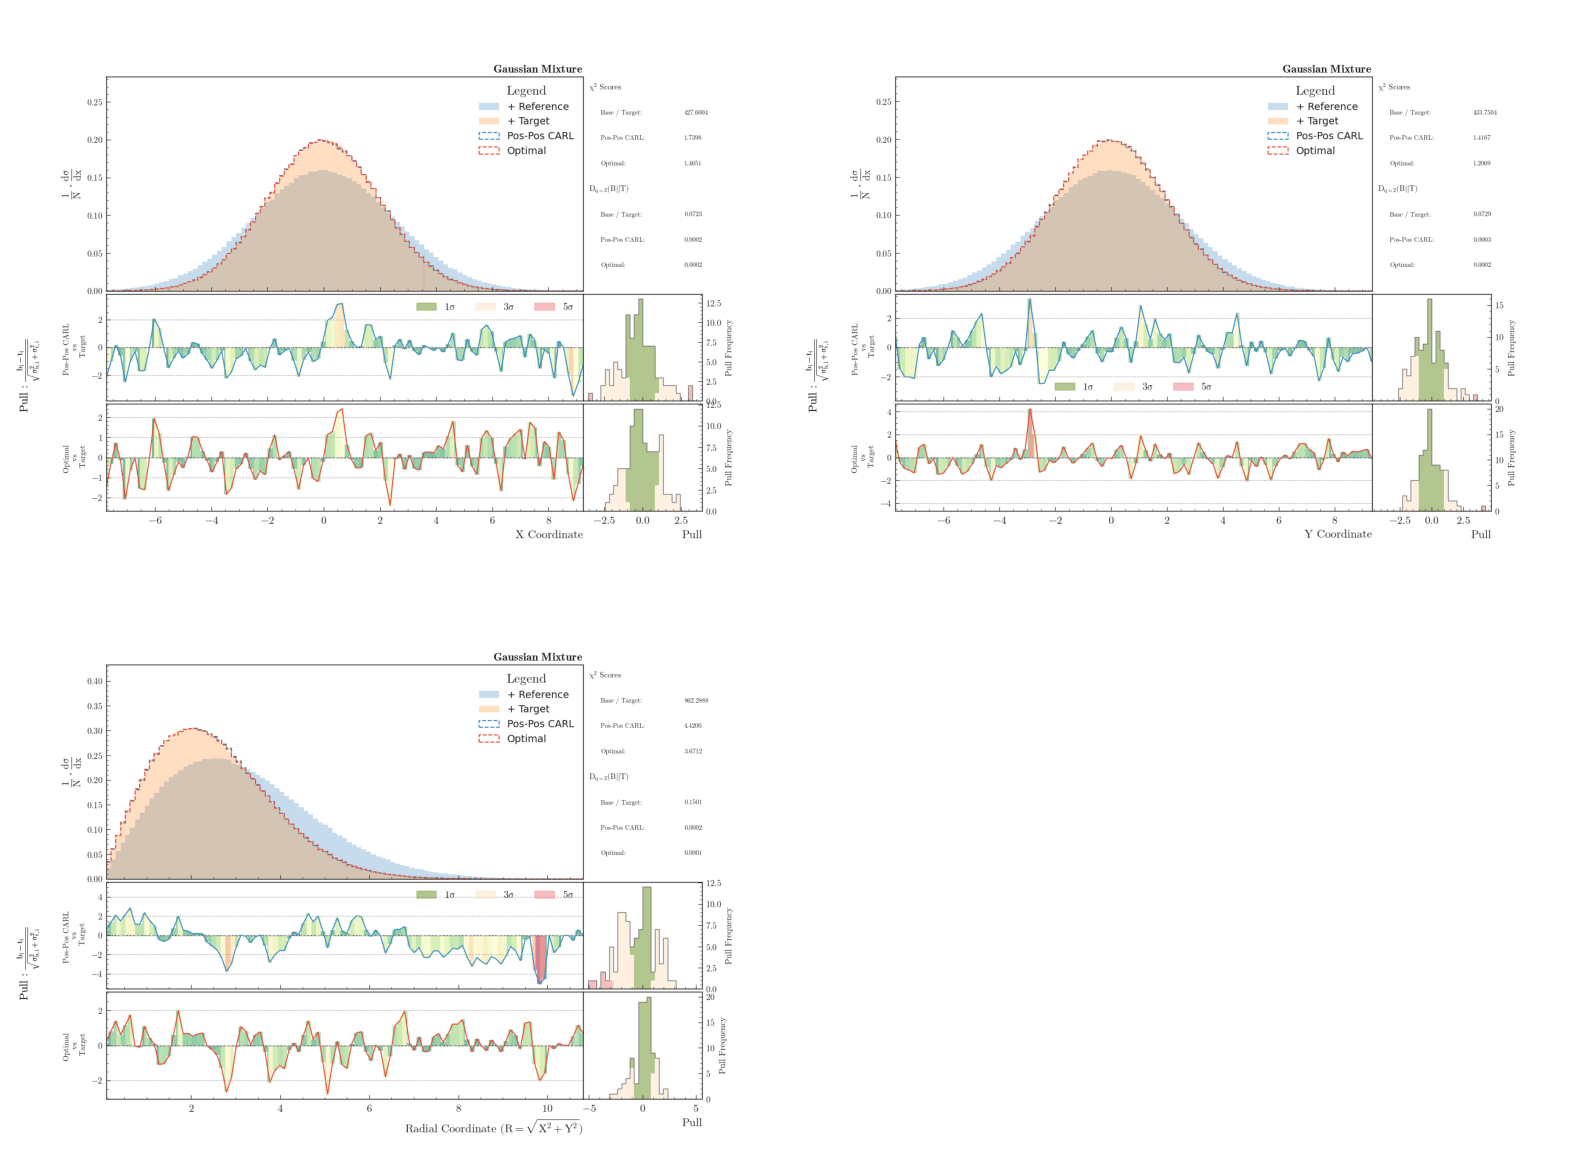

/home/mdrnevich/test/QuasiDRE/ToyModels/../qdre/plotting.py:484: RuntimeWarning: invalid value encountered in divide
  carl_ratio = [carl_hist[0]/x1_hist for carl_hist in carl_hists]


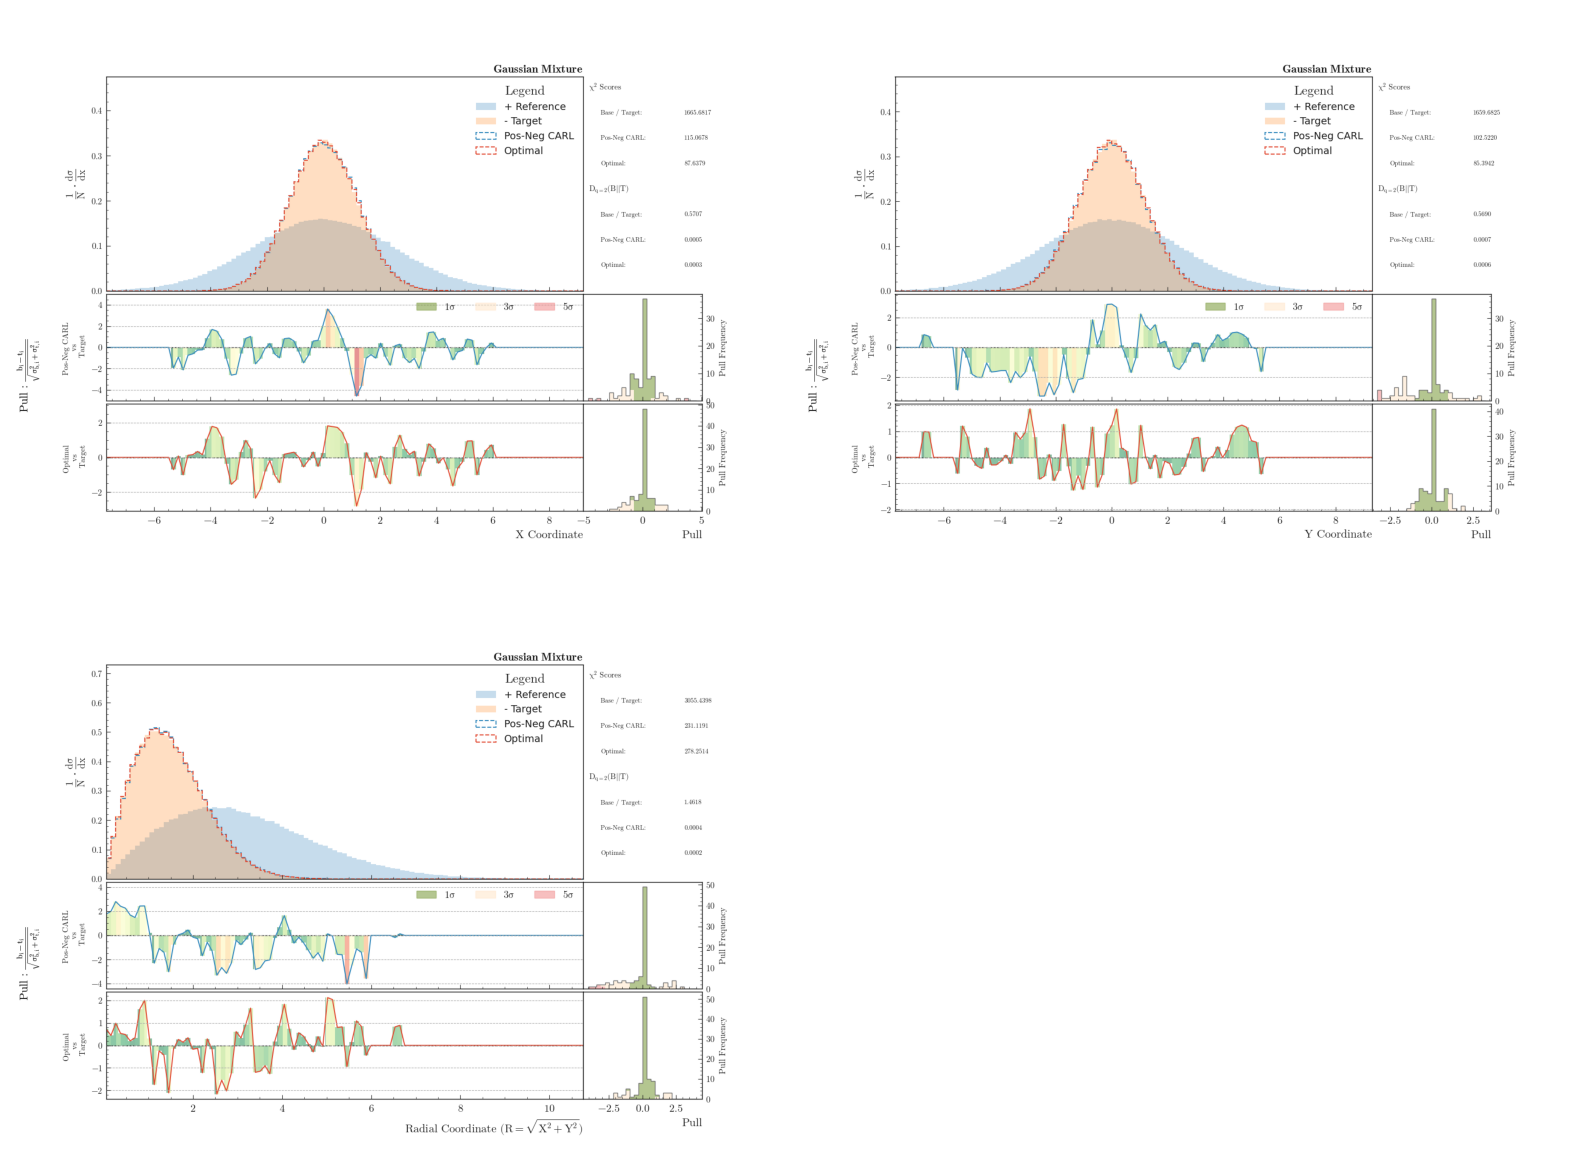

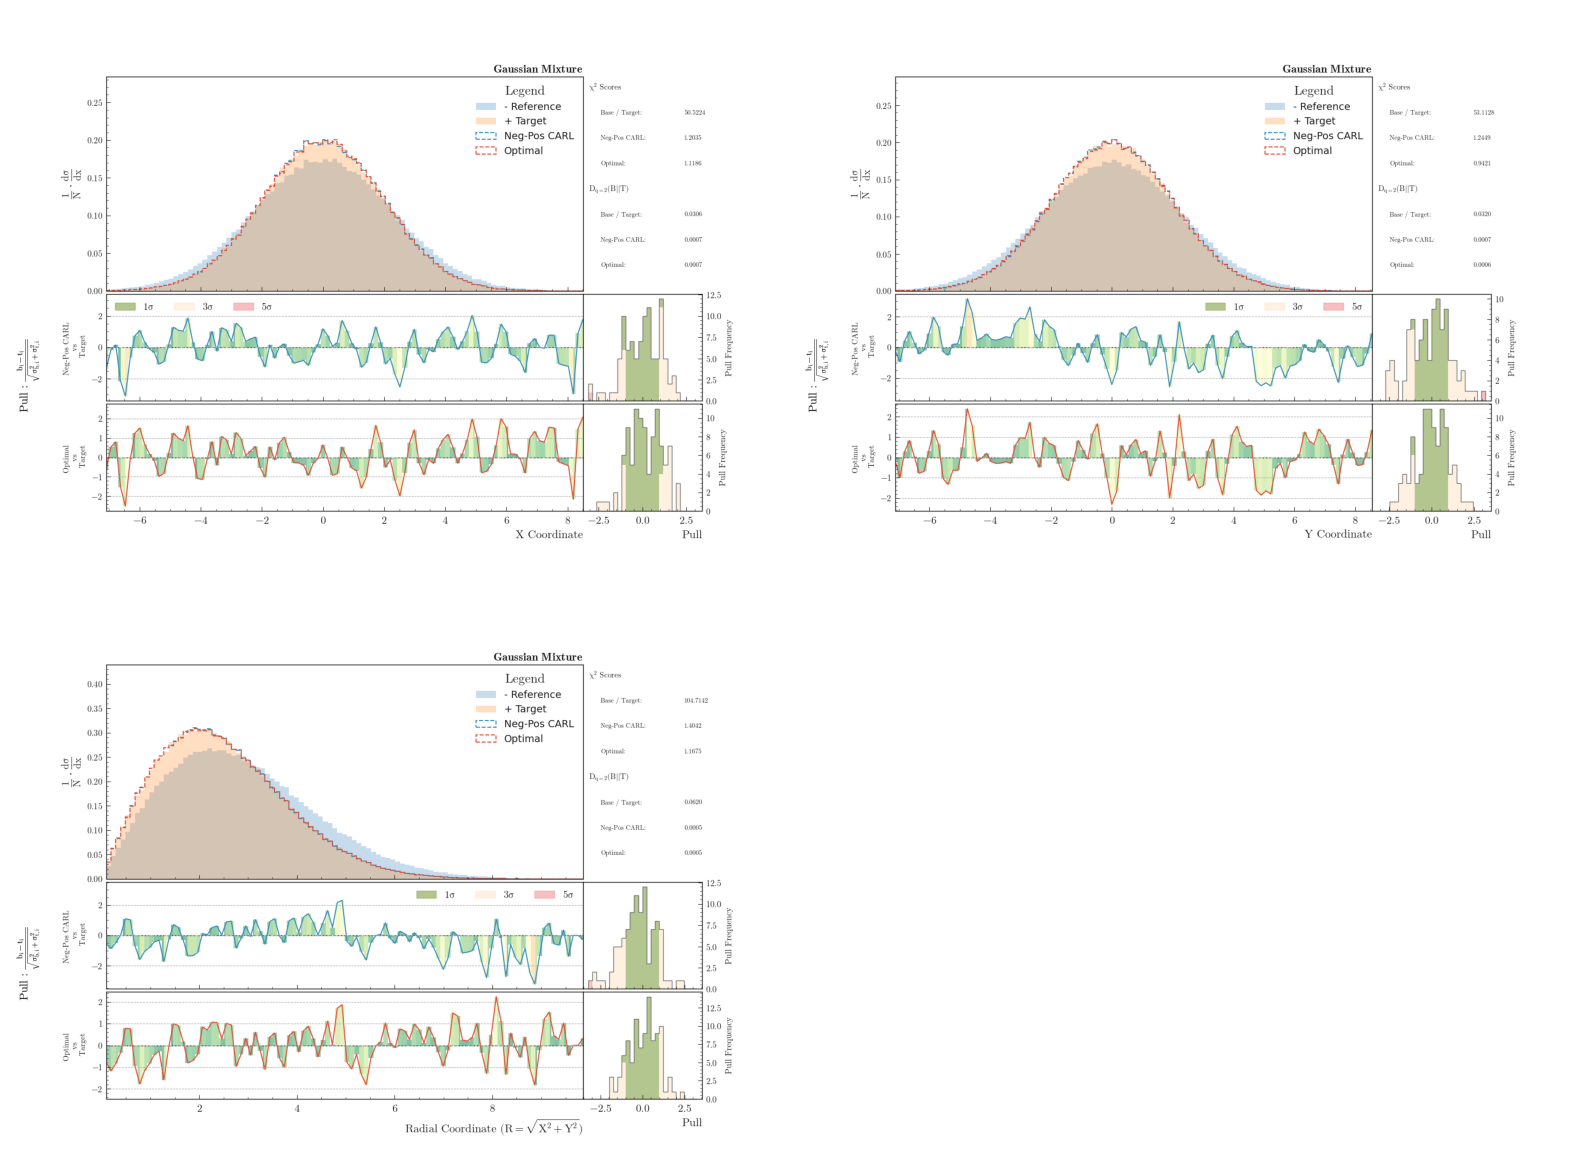

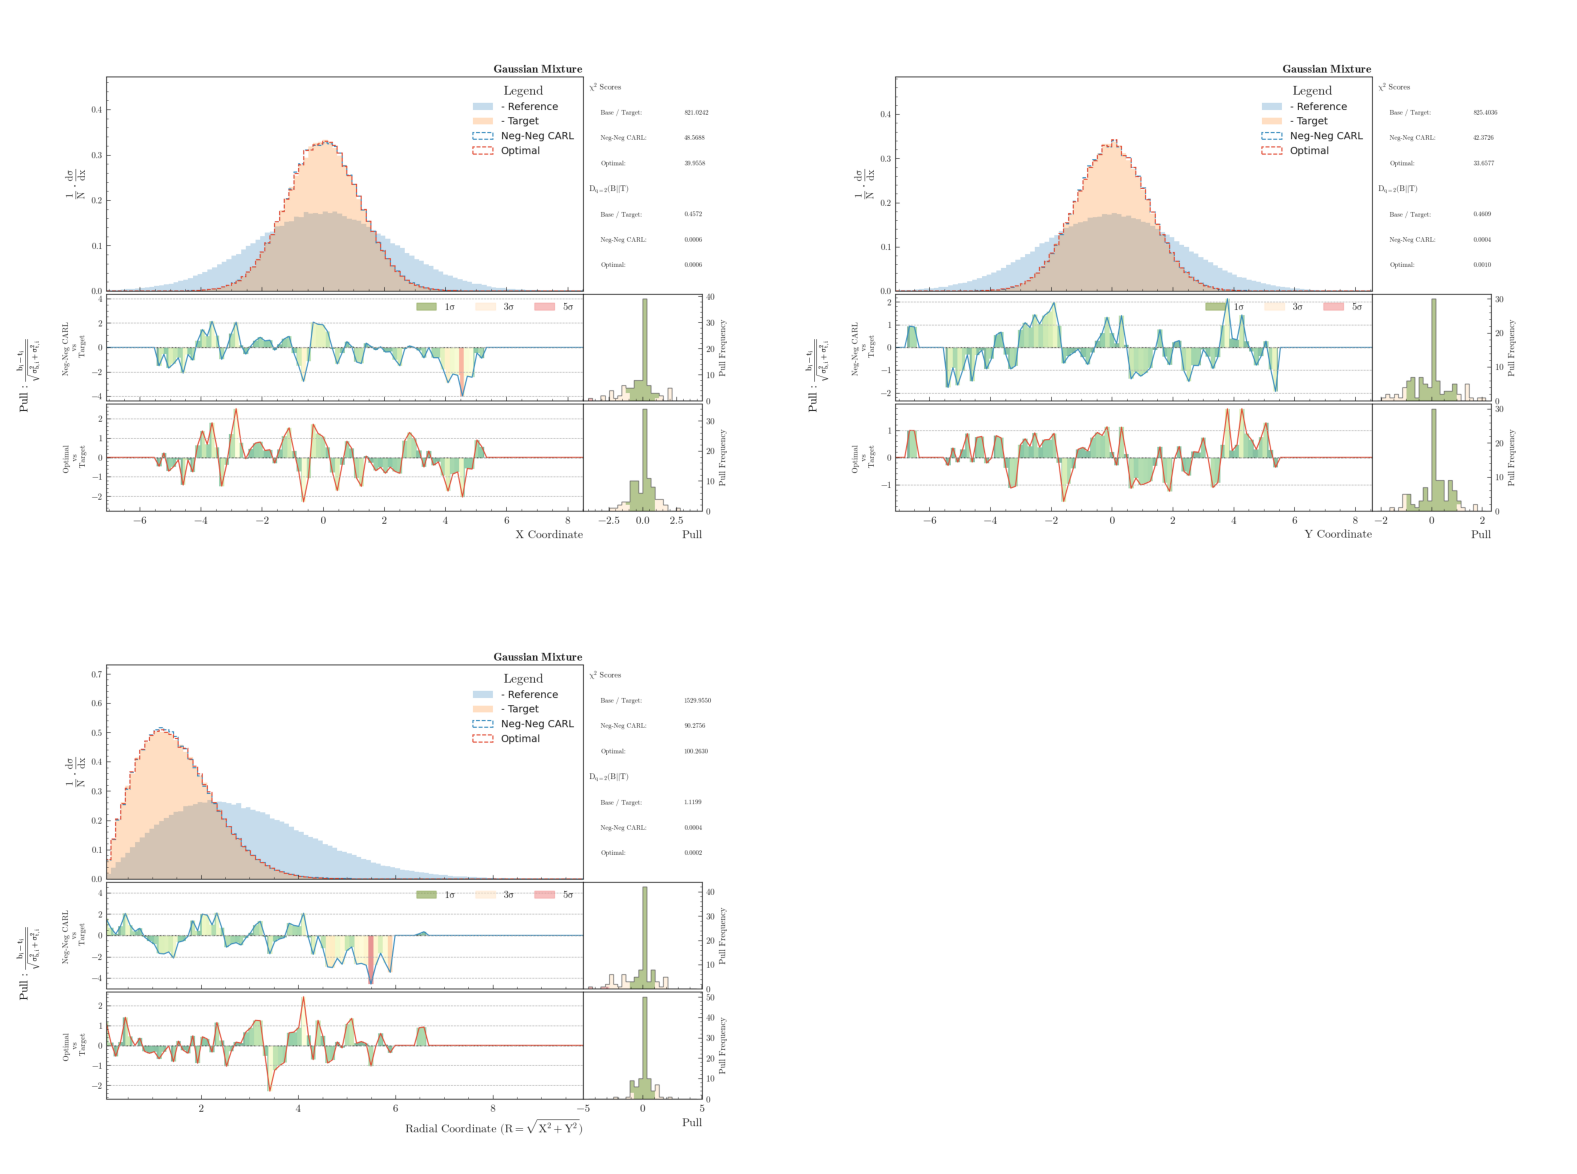

In [21]:
for idx in range(4):
    plot_closure(paired_ratios[idx], test_nominal_loaders[idx], test_target_loaders[idx], nominal_distribution_names[idx], target_distribution_names[idx], carl_names=model_names[idx], percentile_cuts=(0.1, 99.99))